In [ ]:
# Notebook 10: Breast Cancer Prediction Using Machine Learning, Deep Learning and SHAP Explainability

## MSc Data Science and Analytics

### Explainable Machine Learning versus Deep Learning for Early Disease Prediction: A Multi-Dataset Comparative Study

This notebook explores the Breast Cancer Wisconsin Diagnostic Dataset, develops multiple predictive models, compares their performance,
and applies SHAP explainability to interpret the best-performing model.

In [ ]:
## Objectives

The objectives of this notebook are to:

- Load and explore the Breast Cancer dataset.
- Examine data quality and descriptive statistics.
- Split the data into training and testing sets.
- Standardise predictor variables.
- Train Logistic Regression, Random Forest, XGBoost and Deep Learning models.
- Compare model performance.
- Apply SHAP Explainability.

In [1]:
from pathlib import Path

import joblib

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

import shap

plt.style.use("ggplot")

In [2]:
PROJECT_ROOT = Path.cwd().parent

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "breast_cancer"

MODELS_PATH = PROJECT_ROOT / "models"

RESULTS_PATH = PROJECT_ROOT / "results"

FIGURES_PATH = PROJECT_ROOT / "Figures"

MODELS_PATH.mkdir(exist_ok=True)

RESULTS_PATH.mkdir(exist_ok=True)

FIGURES_PATH.mkdir(exist_ok=True)

In [3]:
list(RAW_PATH.iterdir())

[WindowsPath('C:/Users/Syed SAAD ALI/Desktop/healthcare-ai-dissertation/data/raw/breast_cancer/wdbc.data'),
 WindowsPath('C:/Users/Syed SAAD ALI/Desktop/healthcare-ai-dissertation/data/raw/breast_cancer/wdbc.names')]

In [4]:
columns = [
    "id",
    "diagnosis",
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",
    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",
    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]

df = pd.read_csv(
    RAW_PATH / "wdbc.data",
    header=None,
    names=columns
)

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
## Dataset Overview

The Wisconsin Diagnostic Breast Cancer (WDBC) dataset contains features computed from digitised images of fine needle aspirates (FNA) of breast masses.

The objective is to classify tumours as:

- **M** = Malignant
- **B** = Benign

The dataset contains thirty numerical predictor variables describing cell nuclei characteristics and one diagnostic target variable.

In [5]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (569, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  p

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave_points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [11]:
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [12]:
print("Duplicate records:", df.duplicated().sum())

Duplicate records: 0


In [10]:
print("Before")

print(df["diagnosis"].value_counts())

df["diagnosis"] = df["diagnosis"].map({
    "B":0,
    "M":1
})

print()

print("After")

print(df["diagnosis"].value_counts())

Before
diagnosis
B    357
M    212
Name: count, dtype: int64

After
diagnosis
0    357
1    212
Name: count, dtype: int64


In [13]:
df = df.drop("id", axis=1)

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [14]:
print(df["diagnosis"].value_counts())

print()

print(df["diagnosis"].value_counts(normalize=True) * 100)

diagnosis
0    357
1    212
Name: count, dtype: int64

diagnosis
0    62.741652
1    37.258348
Name: proportion, dtype: float64


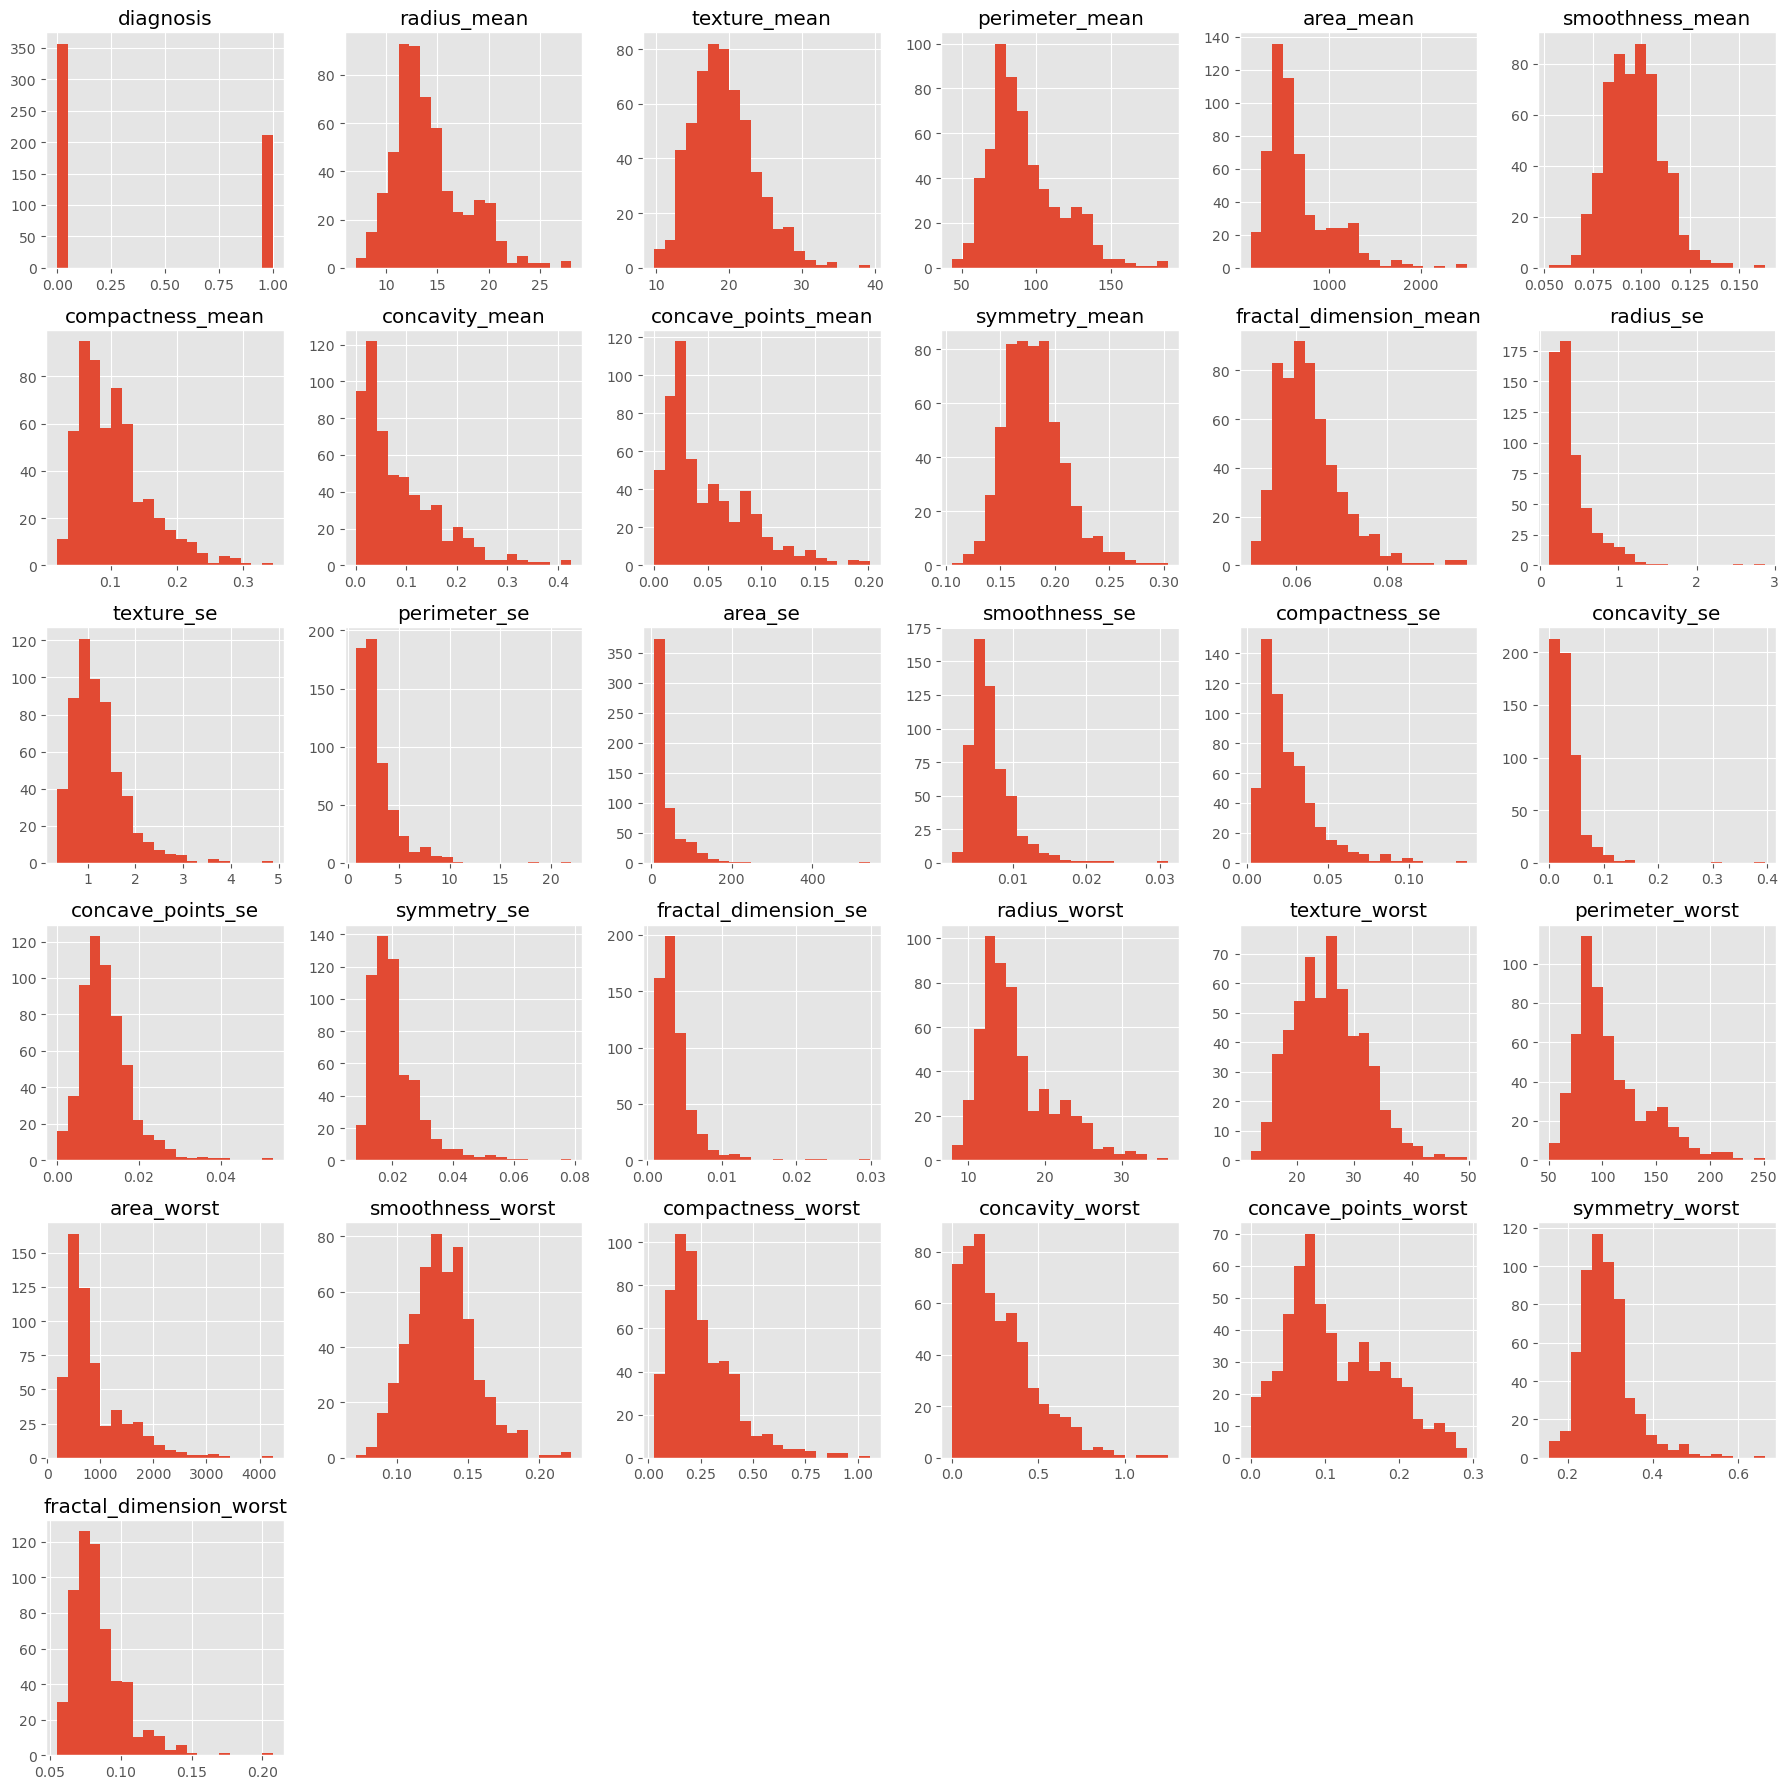

In [15]:
df.hist(
    figsize=(18,18),
    bins=20
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "breast_histograms.png",
    dpi=300
)

plt.show()

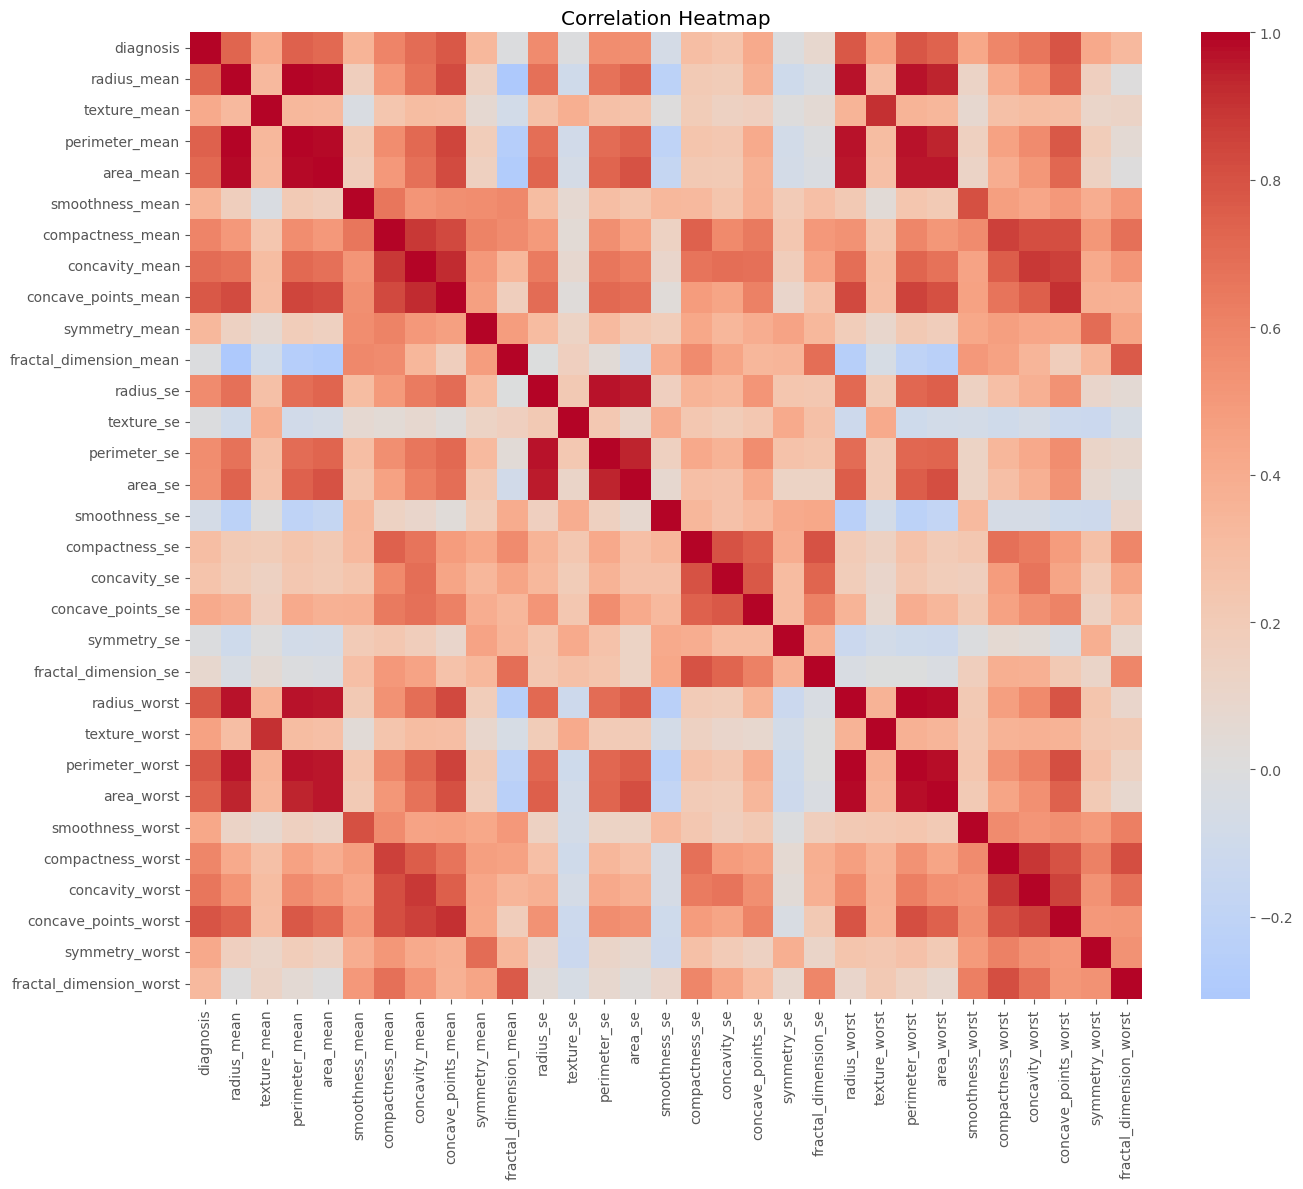

In [16]:
plt.figure(figsize=(14,12))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "breast_heatmap.png",
    dpi=300
)

plt.show()

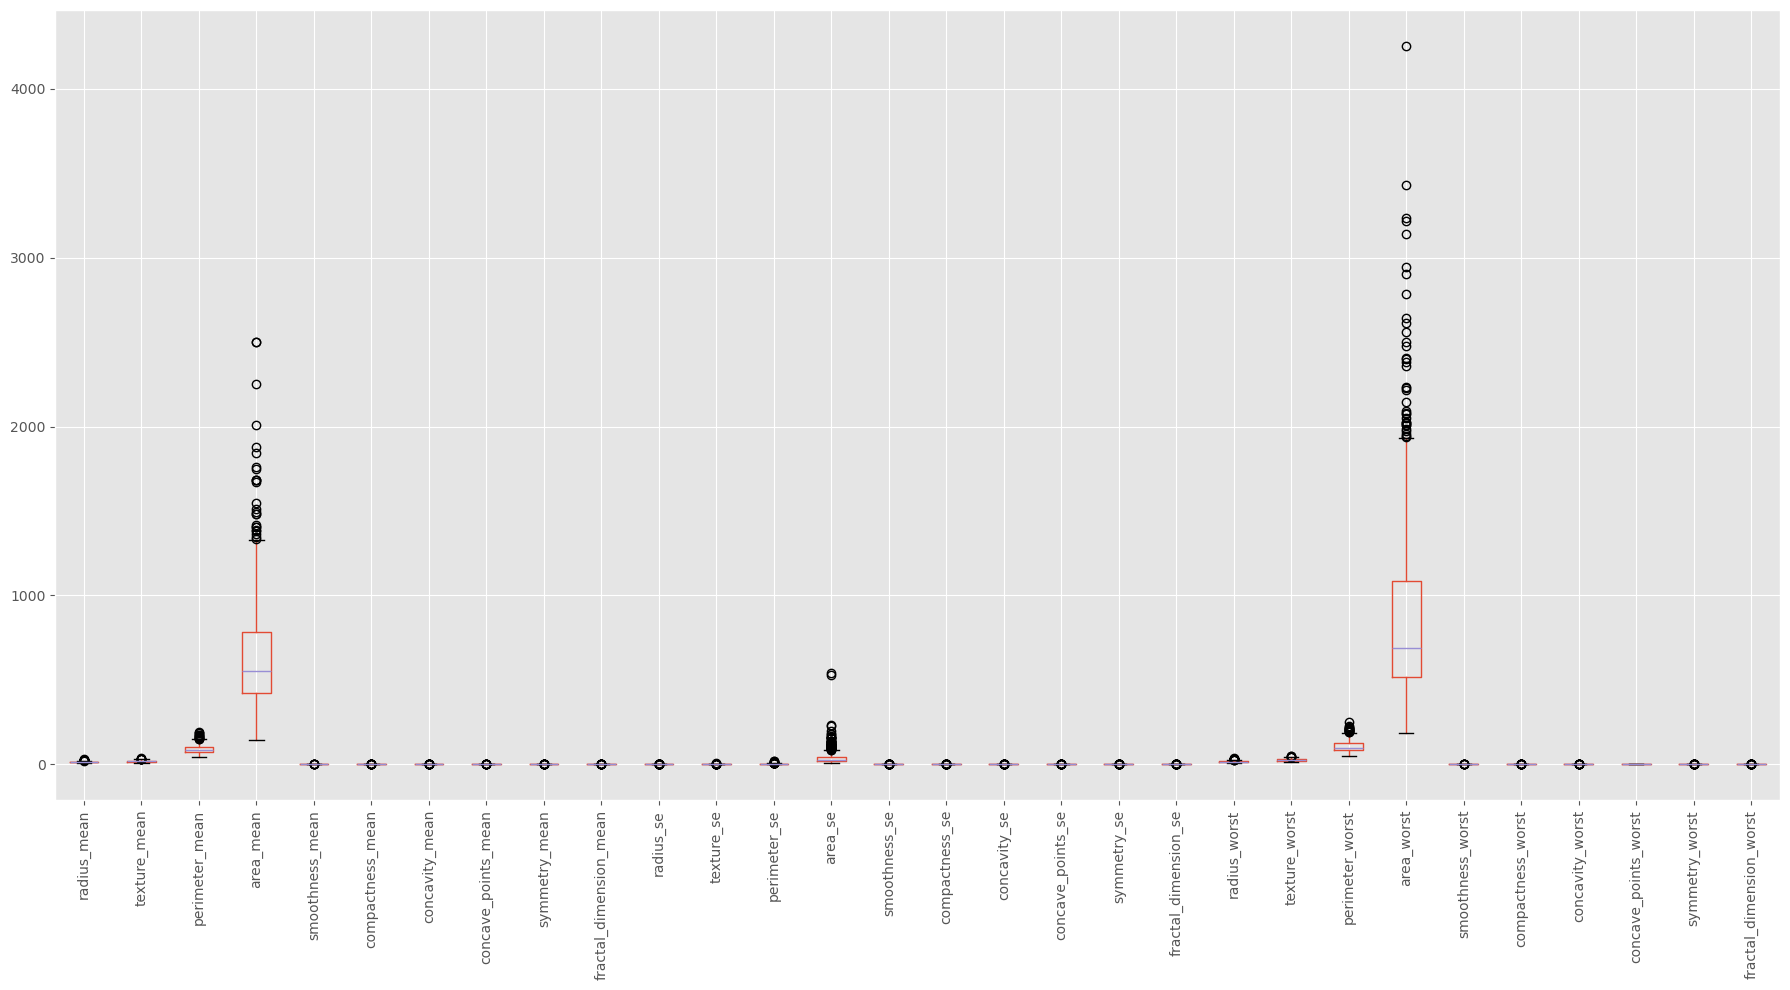

In [17]:
plt.figure(figsize=(18,10))

df.drop("diagnosis", axis=1).boxplot(rot=90)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "breast_boxplots.png",
    dpi=300
)

plt.show()

In [ ]:
## Exploratory Data Analysis

The Breast Cancer Wisconsin Diagnostic dataset contains no missing values or duplicate observations, indicating excellent data quality.
The target variable is moderately imbalanced, with approximately 63% benign and 37% malignant cases.

Correlation analysis reveals that several tumour characteristics are strongly correlated, particularly measurements relating to
tumour size, perimeter, and area. These relationships are expected because they describe similar physical properties of breast cell nuclei.

The dataset is well suited for supervised classification using both machine learning and deep learning models.

In [18]:
X = df.drop(
    "diagnosis",
    axis=1
)

y = df["diagnosis"]

print(X.shape)

print(y.shape)

(569, 30)
(569,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)

print(X_test.shape)

(455, 30)
(114, 30)


In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [21]:
joblib.dump(
    scaler,
    MODELS_PATH / "breast_scaler.pkl"
)

print("Scaler saved.")

Scaler saved.


In [22]:
lr = LogisticRegression(random_state=42)

lr.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [23]:
y_pred_lr = lr.predict(X_test)

y_prob_lr = lr.predict_proba(X_test)[:, 1]

In [24]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_lr), 4))
print("Precision:", round(precision_score(y_test, y_pred_lr), 4))
print("Recall   :", round(recall_score(y_test, y_pred_lr), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_lr), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob_lr), 4))

Accuracy : 0.9649
Precision: 0.975
Recall   : 0.9286
F1 Score : 0.9512
ROC AUC  : 0.996


In [25]:
joblib.dump(
    lr,
    MODELS_PATH / "breast_logistic_regression.pkl"
)

print("Logistic Regression saved.")

Logistic Regression saved.


In [26]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [27]:
y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [28]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_rf), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob_rf), 4))

Accuracy : 0.9737
Precision: 1.0
Recall   : 0.9286
F1 Score : 0.963
ROC AUC  : 0.9929


In [29]:
joblib.dump(
    rf,
    MODELS_PATH / "breast_random_forest.pkl"
)

print("Random Forest saved.")

Random Forest saved.


In [30]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [31]:
y_pred_xgb = xgb.predict(X_test)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [32]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_xgb), 4))
print("Precision:", round(precision_score(y_test, y_pred_xgb), 4))
print("Recall   :", round(recall_score(y_test, y_pred_xgb), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_xgb), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob_xgb), 4))

Accuracy : 0.9737
Precision: 1.0
Recall   : 0.9286
F1 Score : 0.963
ROC AUC  : 0.994


In [33]:
joblib.dump(
    xgb,
    MODELS_PATH / "breast_xgboost.pkl"
)

print("XGBoost saved.")

XGBoost saved.


In [34]:
dl_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

dl_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [35]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [36]:
history = dl_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.2445 - loss: 0.8294 - val_accuracy: 0.5275 - val_loss: 0.7083
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7198 - loss: 0.6245 - val_accuracy: 0.8462 - val_loss: 0.5411
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8874 - loss: 0.4744 - val_accuracy: 0.9011 - val_loss: 0.4169
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9176 - loss: 0.3624 - val_accuracy: 0.9231 - val_loss: 0.3242
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9423 - loss: 0.2798 - val_accuracy: 0.9231 - val_loss: 0.2615
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9451 - loss: 0.2236 - val_accuracy: 0.9231 - val_loss: 0.2201
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9533 - loss: 0.1845 - val_accuracy: 0.9341 - val_loss: 0.1938
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9615 - loss: 0.1565 - val_accuracy: 0.

In [37]:
y_prob_dl = dl_model.predict(X_test)

y_pred_dl = (y_prob_dl > 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [38]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_dl), 4))
print("Precision:", round(precision_score(y_test, y_pred_dl), 4))
print("Recall   :", round(recall_score(y_test, y_pred_dl), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_dl), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob_dl), 4))

Accuracy : 0.9737
Precision: 1.0
Recall   : 0.9286
F1 Score : 0.963
ROC AUC  : 0.9957


In [39]:
dl_model.save(
    MODELS_PATH / "breast_deep_learning.keras"
)

print("Deep Learning model saved.")

Deep Learning model saved.


In [40]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Deep Learning"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_dl)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_dl)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_dl)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_dl)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_dl)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.964912,0.975,0.928571,0.951220,0.996032
1,Random Forest,0.973684,1.000,0.928571,0.962963,0.992890
2,XGBoost,0.973684,1.000,0.928571,0.962963,0.994048
3,Deep Learning,0.973684,1.000,0.928571,0.962963,0.995701


In [41]:
comparison.to_csv(
    RESULTS_PATH / "breast_model_comparison.csv",
    index=False
)

print("Comparison table saved.")

Comparison table saved.


In [42]:
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X)

In [43]:
type(shap_values)

print(np.array(shap_values).shape)

(569, 30, 2)


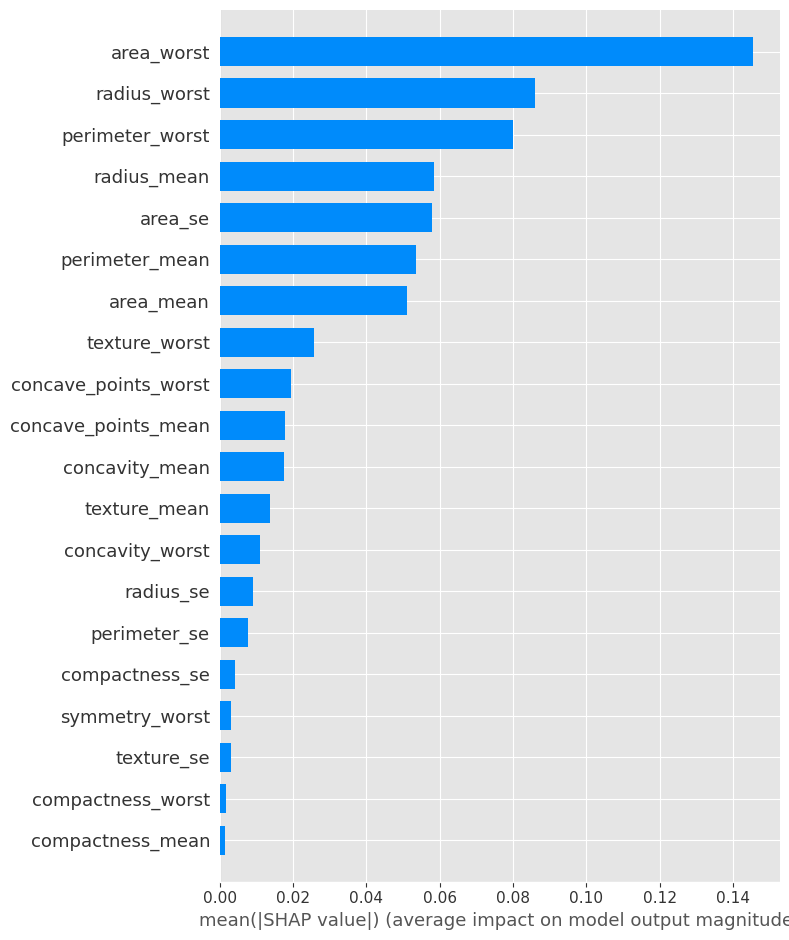

In [44]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values[:, :, 1],
    X,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "breast_shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

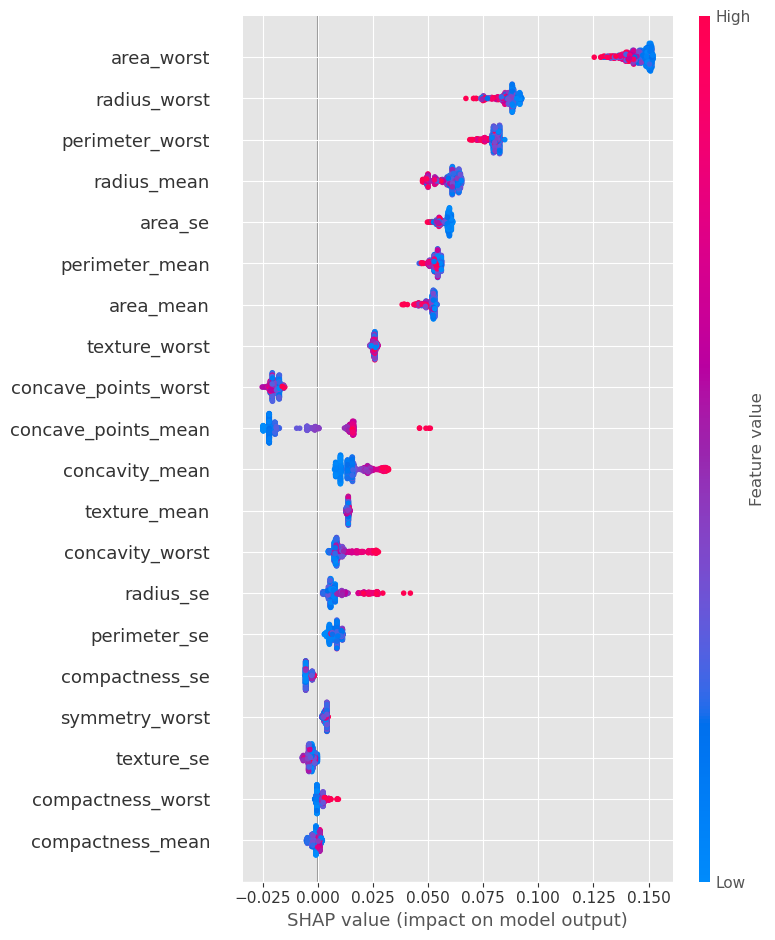

In [45]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values[:, :, 1],
    X,
    show=False
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "breast_shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

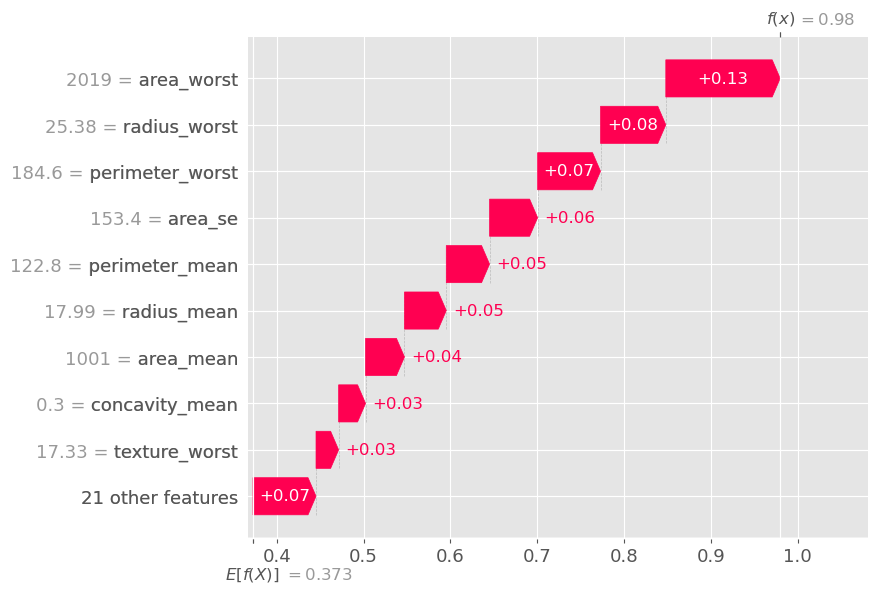

In [46]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0, :, 1],
        base_values=explainer.expected_value[1],
        data=X.iloc[0],
        feature_names=X.columns
    ),
    show=False
)

plt.savefig(
    FIGURES_PATH / "breast_shap_waterfall_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Interpretation

SHAP analysis was applied to the Random Forest classifier to improve the transparency and interpretability of breast cancer predictions.

The SHAP feature importance plot identifies the variables that contribute most to distinguishing benign from malignant tumours.
The SHAP summary plot illustrates both the magnitude and direction of each feature's impact across all observations,
while the waterfall plot explains how individual feature values influence a single patient's prediction.

These explainability techniques provide clinically meaningful insights into the model's decision-making process and
demonstrate that the classifier is both accurate and interpretable.

In [ ]:
# Conclusion

This notebook analysed the Breast Cancer Wisconsin Diagnostic dataset using machine learning and deep learning techniques.

Four predictive models were developed and evaluated. All models achieved excellent predictive performance,
with Random Forest selected for explainability analysis due to its high accuracy and compatibility with SHAP.

The SHAP analysis highlighted the most influential tumour characteristics contributing to classification decisions,
improving model transparency and supporting trustworthy clinical interpretation.

This notebook completes the implementation phase for the three healthcare datasets used in this dissertation.